# CAFE: Generalizable Facial Expression Recognition
### Full Training + Evaluation Notebook
Based on ECCV 2024 — Zhang et al.

**Pipeline:**
```
Input image
  ├── CLIP (frozen) ──────────────────── image_features (512)
  └── ResNet-18 (trained) → sigmoid ──── mask
                                    ↓
                    image_features × sigmoid(x)  = masked features
                                    ↓
              channel separation (7 groups) + channel diverse loss
                                    ↓
                    loss = l_cls + 1.5×l_sep + 5×l_div
```

## 1. Install Dependencies

In [5]:
!pip install ftfy regex tqdm kagglehub
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.1 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-ztxjr629
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-ztxjr629
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=15f62851f2a066753733fe19ae37c6b031b445b2edd4cc42a20c3927e86e46f4
  Stored in directory: /tmp/pip-ephem-wheel-cache-sifxiuk9/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


## 2. Mount Google Drive

( make a folder in drive "deeplearning" and upload the .pth and .json filess )

.pth file --> prelearned weight from resnet for our cnn backbone

**Run this code only if using Google Colab** (skip if using Elice)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# ── Your Drive folder path ───────────────────────────────────────────
DRIVE_FOLDER = '/content/drive/MyDrive/deeplearning'
# ────────────────────────────────────────────────────────────────────

print('Files in your deeplearning folder:')
for f in os.listdir(DRIVE_FOLDER):
    print(' ', f)

## 3. Set File Paths from Drive
Set training dataset

In [2]:
import os
import kagglehub

if os.path.exists('/content/drive'):
  FILE_FOLDER = DRIVE_FOLDER
else:
  FILE_FOLDER = '.'

# ── ResNet-18 MS-Celeb weights (from Drive or Local) ──────────────────────────
MSCELEB_PATH = os.path.join(FILE_FOLDER, 'resnet18_msceleb.pth')

# ── Copy kaggle.json from Drive ──────────────────────────────────────
!mkdir -p ~/.kaggle
!cp "{FILE_FOLDER}/kaggle.json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

# ── Download dataset from Kaggle ─────────────────────────────────────

# RAF-DB
train_dataset_path = kagglehub.dataset_download("shuvoalok/raf-db-dataset")

# FERPlus ___________________________________________________________________________________ UNCOMMENT for FERplus
# train_dataset_path = kagglehub.dataset_download("arnabkumarroy02/ferplus")

# affectnet
# train_dataset_path = kagglehub.dataset_download("mstjebashazida/affectnet")

# MMA
# train_dataset_path = kagglehub.dataset_download("mahmoudima/mma-facial-expression")

# SFEW
# train_dataset_path = kagglehub.dataset_download("vlntnstarodub/datasetsfew")

# ────────────────────────────────────────────────────────────────────

print('MS-Celeb weights found :', os.path.exists(MSCELEB_PATH))
print('Train Dataset path           :', train_dataset_path)

# See what's inside
print('\n Train Dataset contents:')
for f in os.listdir(train_dataset_path):
    print(' ', f)

cp: cannot stat './kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


100%|██████████| 37.7M/37.7M [00:00<00:00, 112MB/s]

Extracting files...


MS-Celeb weights found : False
Train Dataset path           : /root/.cache/kagglehub/datasets/shuvoalok/raf-db-dataset/versions/2

 Train Dataset contents:
  test_labels.csv
  DATASET
  train_labels.csv


Set test dataset

In [3]:
# ── Download dataset from Kaggle ─────────────────────────────────────

# RAF-DB
test_dataset_path = kagglehub.dataset_download("shuvoalok/raf-db-dataset")

# FERPlus ___________________________________________________________________________________ UNCOMMENT for FERplus
# test_dataset_path = kagglehub.dataset_download("arnabkumarroy02/ferplus")

# affectnet
# test_dataset_path = kagglehub.dataset_download("mstjebashazida/affectnet")

# MMA
# test_dataset_path = kagglehub.dataset_download("mahmoudima/mma-facial-expression")

# SFEW
# test_dataset_path = kagglehub.dataset_download("vlntnstarodub/datasetsfew")

# ────────────────────────────────────────────────────────────────────

print('MS-Celeb weights found :', os.path.exists(MSCELEB_PATH))
print('Test Dataset path           :', test_dataset_path)

# See what's inside
print('\n Test Dataset contents:')
for f in os.listdir(test_dataset_path):
    print(' ', f)

MS-Celeb weights found : False
Test Dataset path           : /root/.cache/kagglehub/datasets/shuvoalok/raf-db-dataset/versions/2

 Test Dataset contents:
  test_labels.csv
  DATASET
  train_labels.csv


## 4. Imports

In [11]:
import os
import cv2
import math
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
from torchvision import transforms
from torch.autograd import Variable
from torch.nn.modules.module import Module
from torch.nn.modules.utils import _pair
from torch.nn.parameter import Parameter

import clip
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Load CLIP model (frozen)
clip_model, preprocess = clip.load("ViT-B/32", device=device)
print('CLIP loaded.')

Device: cpu


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 205MiB/s]


CLIP loaded.


Create label maps for consistent labels between datasets.

In [6]:
raf_map = {
    '1': 5,  # surprise
    '2': 2,  # fear
    '3': 1,  # disgust
    '4': 3,  # happy
    '5': 4,  # sad
    '6': 0,  # angry
    '7': 6   # neutral
}

ferplus_map = {
    'fear': 2,
    'suprise': 5,
    'angry': 0,
    'neutral': 6,
    'sad': 4,
    'disgust': 1,
    'happy': 3
}

affectnet_train_map = {
    'anger': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'neutral': 6,
    'sad': 4,
    'surprise': 5
}

affectnet_test_map = {
    'Anger': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'neutral': 6,
    'sad': 4,
    'surprise': 5
}

sfew_map = {
    'Angry': 0,
    'Disgust': 1,
    'Fear': 2,
    'Happy': 3,
    'Neutral': 6,
    'Sad': 4,
    'Surprise': 5
}

mma_map = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'neutral': 6,
    'sad': 4,
    'surprise': 5
}

## 5. Dataset Loader
Set training dataset

In [7]:
# ── DATASET PATHS — switch by commenting/uncommenting ───────────────

# RAF-DB #___________________________________________________________________________________ UNCOMMENT for RAF-DB
TRAIN_DATASET_PATH = os.path.join(train_dataset_path, 'DATASET')
TRAIN_DATASET_NAME = 'RAFDB'
TRAIN_MAP = raf_map
TRAIN_PHASE = 'train'

# FERPlus #___________________________________________________________________________________ UNCOMMENT for FERplus
# TRAIN_DATASET_PATH = train_dataset_path
# TRAIN_DATASET_NAME = 'FERPlus'
# TRAIN_MAP = ferplus_map
# TRAIN_PHASE = 'train'
# VALIDATION_PHASE = 'validation'

#AffectNET
# TRAIN_DATASET_PATH = os.path.join(train_dataset_path,'archive (3)')
# TRAIN_DATASET_NAME = 'AffectNET'
# TRAIN_MAP = affectnet_train_map
# TRAIN_PHASE = 'Train'

# MMA
#TRAIN_DATASET_PATH = os.path.join(train_dataset_path,'MMAFEDB')
#TRAIN_DATASET_NAME = 'MMA'
# TRAIN_MAP = mma_map
# TRAIN_PHASE = 'train'
# VALIDATION_PHASE = 'valid'

# SFEW
#TRAIN_DATASET_PATH = train_dataset_path
#TRAIN_DATASET_NAME = 'SFEW'
# TRAIN_MAP = sfew_map
# TRAIN_PHASE = 'Train'

# ────────────────────────────────────────────────────────────────────

# Class names — same for both datasets (7 basic expressions)
# RAF-DB label order (1-indexed in txt, we subtract 1):
# 1=Surprise, 2=Fear, 3=Disgust, 4=Happy, 5=Sad, 6=Angry, 7=Neutral
CLASS_NAMES = ['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']
NUM_CLASSES = 7

print(f'Using dataset: {TRAIN_DATASET_NAME}')
print(f'Path: {TRAIN_DATASET_PATH}')

Using dataset: RAFDB
Path: /root/.cache/kagglehub/datasets/shuvoalok/raf-db-dataset/versions/2/DATASET


Set test dataset

In [8]:
# ── DATASET PATHS — switch by commenting/uncommenting ───────────────

# RAF-DB #___________________________________________________________________________________ UNCOMMENT for RAF-DB
TEST_DATASET_PATH = os.path.join(test_dataset_path, 'DATASET')
TEST_DATASET_NAME = 'RAFDB'
TEST_MAP = raf_map
TEST_PHASE = 'test'

# FERPlus #___________________________________________________________________________________ UNCOMMENT for FERplus
# TEST_DATASET_PATH = test_dataset_path
# TEST_DATASET_NAME = 'FERPlus'
# TEST_MAP = ferplus_map
# TEST_PHASE = 'test'

#AffectNET
# TEST_DATASET_PATH = os.path.join(test_dataset_path,'archive (3)')
# TEST_DATASET_NAME = 'AffectNET'
# TEST_MAP = affectnet_test_map
# TEST_PHASE = 'Test'

# MMA
# TEST_DATASET_PATH = os.path.join(test_dataset_path,'MMAFEDB')
# TEST_DATASET_NAME = 'MMA'
# TEST_MAP = mma_map
# TEST_PHASE = 'test'

# SFEW
# TEST_DATASET_PATH = test_dataset_path
# TEST_DATASET_NAME = 'SFEW'
# TEST_MAP = sfew_map
# TEST_PHASE = 'Val'

# ────────────────────────────────────────────────────────────────────

# Class names — same for both datasets (7 basic expressions)
# RAF-DB label order (1-indexed in txt, we subtract 1):
# 1=Surprise, 2=Fear, 3=Disgust, 4=Happy, 5=Sad, 6=Angry, 7=Neutral
CLASS_NAMES = ['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']
NUM_CLASSES = 7

print(f'Using dataset: {TEST_DATASET_NAME}')
print(f'Path: {TEST_DATASET_PATH}')

Using dataset: RAFDB
Path: /root/.cache/kagglehub/datasets/shuvoalok/raf-db-dataset/versions/2/DATASET


#Integrate Albumentations

In [12]:
def add_g(image_array, mean=0.0, var=30):
    """Add Gaussian noise"""
    std = var ** 0.5
    image_add = image_array + np.random.normal(mean, std, image_array.shape)
    image_add = np.clip(image_add, 0, 255).astype(np.uint8)
    return image_add

def flip_image(image_array):
    return cv2.flip(image_array, 1)

def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True


class FolderDataset(data.Dataset):

    def __init__(self, root, phase='train', transform=None, label_map=None):
        self.transform = transform
        self.aug_func  = [flip_image, add_g]
        self.phase     = phase
        self.label_map = label_map

        split_dir = os.path.join(root, phase)
        self.classes = sorted([c for c in os.listdir(split_dir) if (c != 'contempt' and c != 'Contempt')])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        self.file_paths = []
        self.labels     = []

        for cls in self.classes:
            cls_dir = os.path.join(split_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.file_paths.append(os.path.join(cls_dir, fname))
                    if self.label_map is not None:
                      mapped_label = self.label_map[cls]
                    else:
                      mapped_label = self.class_to_idx[cls]

                    self.labels.append(mapped_label)

        print(f'[{phase}] {len(self.file_paths)} samples | classes: {self.classes}')

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        label = self.labels[idx]
        image = cv2.imread(self.file_paths[idx])
        image = image[:, :, ::-1]  # BGR → RGB

        # Augmentation during training
        if self.phase.lower() == 'train':
            if random.uniform(0, 1) > 0.5:
                image = add_g(image)

        if self.transform is not None:
            image = self.transform(image)

        # Flipped image (used by some loss variants)
        image_flip = transforms.RandomHorizontalFlip(p=1)(image)

        return image, label, idx, image_flip

In [23]:
from torch.utils.data import random_split

# Transforms — from original CAFE code
train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomHorizontalFlip(),
    transforms.RandomErasing(scale=(0.02, 0.25))
])

eval_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── Dataset and Loaders ──────────────────────────────────────────────
BATCH_SIZE = 32
NUM_WORKERS = 4

train_dataset = FolderDataset(TRAIN_DATASET_PATH, phase=TRAIN_PHASE, transform=train_transforms, label_map=TRAIN_MAP)
test_dataset  = FolderDataset(TEST_DATASET_PATH, phase=TEST_PHASE,  transform=eval_transforms, label_map=TEST_MAP)

if TRAIN_DATASET_NAME in ['RAFDB', 'AffectNET', 'SFEW']:
    train_size = int(0.8 * len(train_dataset))
    valid_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, valid_size])
else:
  val_dataset = FolderDataset(TRAIN_DATASET_PATH, phase=VALIDATION_PHASE, transform=eval_transforms, label_map=TRAIN_MAP)


train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE,
                               shuffle=True,  num_workers=NUM_WORKERS, pin_memory=False)
val_loader = data.DataLoader(val_dataset, batch_size=BATCH_SIZE,
                               shuffle=True,  num_workers=NUM_WORKERS, pin_memory=False)
test_loader  = data.DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                               shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

[train] 12271 samples | classes: ['1', '2', '3', '4', '5', '6', '7']
[test] 3068 samples | classes: ['1', '2', '3', '4', '5', '6', '7']
Train batches: 307 | Test batches: 96


## 6. CAFE Model Architecture
Exact code from `ours_CAFE.py`

In [14]:
# ── Custom MaxPool2d (used in channel separation) ────────────────────
class my_MaxPool2d(Module):
    def __init__(self, kernel_size, stride=None, padding=0, dilation=1,
                 return_indices=False, ceil_mode=False):
        super(my_MaxPool2d, self).__init__()
        self.kernel_size    = kernel_size
        self.stride         = stride or kernel_size
        self.padding        = padding
        self.dilation       = dilation
        self.return_indices = return_indices
        self.ceil_mode      = ceil_mode

    def forward(self, input):
        input = input.transpose(3, 1)
        input = F.max_pool2d(input, self.kernel_size, self.stride,
                             self.padding, self.dilation, self.ceil_mode,
                             self.return_indices)
        input = input.transpose(3, 1).contiguous()
        return input


# ── Channel dropping mask ────────────────────────────────────────────
def Mask(nb_batch):
    """
    Generates random channel drop mask.
    7 expression groups × (63 or 64 channels each) = 512 total
    Drops 10 channels per group randomly.
    """
    bar = []
    for i in range(7):
        foo = [1] * 63 + [0] * 10
        if i == 6:
            foo = [1] * 64 + [0] * 10  # last group gets 1 extra channel
        random.shuffle(foo)
        bar += foo
    bar = [bar for _ in range(nb_batch)]
    bar = np.array(bar).astype('float32')
    bar = bar.reshape(nb_batch, 512, 1, 1)
    bar = torch.from_numpy(bar).to(device)
    bar = Variable(bar)
    return bar


# ── Channel separation + channel diverse loss ────────────────────────
def supervisor(x, targets, cnum=73):
    """
    Computes l_sep (channel separation loss) and l_div (channel diverse loss).

    x       : masked features (N, 512)
    targets : expression labels (N,)
    cnum    : channels per expression group (73 for groups 0-5, 74 for group 6)

    Returns: [l_sep, l_div]
    """
    # l_div — channel diverse loss
    branch = x
    branch = branch.reshape(branch.size(0), branch.size(1), 1, 1)
    branch = my_MaxPool2d(kernel_size=(1, cnum), stride=(1, cnum))(branch)
    branch = branch.reshape(branch.size(0), branch.size(1),
                            branch.size(2) * branch.size(3))
    loss_2 = 1.0 - 1.0 * torch.mean(torch.sum(branch, 2)) / cnum

    # l_sep — channel separation cross-entropy loss
    mask    = Mask(x.size(0))
    branch_1 = x.reshape(x.size(0), x.size(1), 1, 1) * mask
    branch_1 = my_MaxPool2d(kernel_size=(1, cnum), stride=(1, cnum))(branch_1)
    branch_1 = branch_1.view(branch_1.size(0), -1)
    loss_1   = nn.CrossEntropyLoss()(branch_1, targets)

    return [loss_1, loss_2]


# ── Custom ResNet-18 BasicBlock ──────────────────────────────────────
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=False):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)

        if downsample:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.downsample = None

    def forward(self, x):
        i = x
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        if self.downsample is not None:
            i = self.downsample(i)
        x += i
        return self.relu(x)


# ── Custom ResNet ────────────────────────────────────────────────────
class ResNet(nn.Module):
    def __init__(self, block, n_blocks, channels, output_dim):
        super().__init__()
        self.in_channels = channels[0]
        assert len(n_blocks) == len(channels) == 4

        self.conv1   = nn.Conv2d(3, self.in_channels, kernel_size=7,
                                  stride=2, padding=3, bias=False)
        self.bn1     = nn.BatchNorm2d(self.in_channels)
        self.relu    = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1  = self.get_resnet_layer(block, n_blocks[0], channels[0])
        self.layer2  = self.get_resnet_layer(block, n_blocks[1], channels[1], stride=2)
        self.layer3  = self.get_resnet_layer(block, n_blocks[2], channels[2], stride=2)
        self.layer4  = self.get_resnet_layer(block, n_blocks[3], channels[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(self.in_channels, output_dim)

    def get_resnet_layer(self, block, n_blocks, channels, stride=1):
        layers = []
        downsample = (self.in_channels != block.expansion * channels)
        layers.append(block(self.in_channels, channels, stride, downsample))
        for _ in range(1, n_blocks):
            layers.append(block(block.expansion * channels, channels))
        self.in_channels = block.expansion * channels
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        h = x.view(x.shape[0], -1)
        x = self.fc(h)
        return x, h


# ── CAFE Main Model ──────────────────────────────────────────────────
class Model(nn.Module):
    """
    CAFE model — exact implementation from ours_CAFE.py

    Forward (train): returns (logits, [l_sep, l_div])
    Forward (test) : returns (logits, logits)

    Loss = l_cls + 1.5 * l_sep + 5 * l_div
    """
    def __init__(self, msceleb_path, num_classes=7, drop_rate=0):
        super(Model, self).__init__()

        # Build ResNet-18 and load MS-Celeb weights
        res18 = ResNet(block=BasicBlock, n_blocks=[2, 2, 2, 2],
                       channels=[64, 128, 256, 512], output_dim=1000)
        msceleb_model = torch.load(msceleb_path, map_location='cpu')
        state_dict    = msceleb_model['state_dict']
        res18.load_state_dict(state_dict, strict=False)
        print('MS-Celeb weights loaded.')

        self.drop_rate = drop_rate
        self.features  = nn.Sequential(*list(res18.children())[:-2])   # conv layers
        self.features2 = nn.Sequential(*list(res18.children())[-2:-1]) # avgpool

        fc_in_dim = list(res18.children())[-1].in_features  # 512
        self.fc   = nn.Linear(fc_in_dim, num_classes)        # 512 → 7

        self.parm = {}
        for name, parameters in self.fc.named_parameters():
            print(name, ':', parameters.size())
            self.parm[name] = parameters

    def forward(self, x, clip_model, targets, phase='train'):
        # CLIP features — frozen, no grad
        with torch.no_grad():
            image_features = clip_model.encode_image(x)
            image_features = image_features.float()  # ensure float32

        # ResNet-18 features
        x  = self.features(x)       # (N, 512, 7, 7)
        x  = self.features2(x)      # (N, 512, 1, 1)
        x  = x.view(x.size(0), -1)  # (N, 512)

        # Sigmoid mask + CLIP feature selection
        if phase == 'train':
            MC_loss = supervisor(image_features * torch.sigmoid(x),
                                 targets, cnum=73)

        x   = image_features * torch.sigmoid(x)  # (N, 512) masked features
        out = self.fc(x)                           # (N, 7) logits

        if phase == 'train':
            return out, MC_loss
        else:
            return out, out


print('Model architecture defined.')

Model architecture defined.


## 7. Initialize Model, Optimizer, Scheduler

In [19]:
setup_seed(3407)

model = Model(msceleb_path=MSCELEB_PATH, num_classes=NUM_CLASSES)
model.to(device)

# From original CAFE code
optimizer = torch.optim.Adam(model.parameters(), lr=0.0002, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

EPOCHS = 20

print(f'\nOptimizer : Adam  lr=0.0002, wd=1e-4')
print(f'Scheduler : ExponentialLR gamma=0.9')
print(f'Epochs    : {EPOCHS}')

MS-Celeb weights loaded.
weight : torch.Size([7, 512])
bias : torch.Size([7])

Optimizer : Adam  lr=0.0002, wd=1e-4
Scheduler : ExponentialLR gamma=0.9
Epochs    : 20


## 8. Train and Test Functions

In [20]:
def train_one_epoch(model, train_loader, optimizer, scheduler, device):
    """
    One training epoch.
    loss = l_cls + 5 * l_div + 1.5 * l_sep
    """
    model.train()
    running_loss = 0.0
    iter_cnt     = 0
    correct_sum  = 0

    for imgs, labels, indexes, imgs_flip in train_loader:
        imgs   = imgs.to(device)
        labels = labels.to(device)

        output, MC_loss = model(imgs, clip_model, labels, phase='train')

        # Total loss — from original CAFE code
        loss_cls = nn.CrossEntropyLoss()(output, labels)   # l_cls
        loss     = loss_cls + 5 * MC_loss[1] + 1.5 * MC_loss[0]  # + l_div + l_sep

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        iter_cnt += 1
        _, predicts  = torch.max(output, 1)
        correct_sum  += torch.eq(predicts, labels).sum()
        running_loss += loss

    scheduler.step()
    running_loss = running_loss / iter_cnt
    acc = correct_sum.float() / float(train_loader.dataset.__len__())
    return acc.item(), running_loss.item()


def test_model(model, test_loader, device):
    """
    Evaluation — uses only l_cls path (no separation/diverse at test time).
    """
    model.eval()
    with torch.no_grad():
        running_loss = 0.0
        iter_cnt     = 0
        correct_sum  = 0
        data_num     = 0

        for imgs, labels, indexes, imgs_flip in test_loader:
            imgs   = imgs.to(device)
            labels = labels.to(device)

            outputs, _ = model(imgs, clip_model, labels, phase='test')
            loss       = nn.CrossEntropyLoss()(outputs, labels)

            iter_cnt  += 1
            _, predicts = torch.max(outputs, 1)
            correct_sum += torch.eq(predicts, labels).sum()
            running_loss += loss
            data_num     += outputs.size(0)

        running_loss = running_loss / iter_cnt
        test_acc     = correct_sum.float() / float(data_num)

    return test_acc.item(), running_loss.item()


print('Train and test functions ready.')

Train and test functions ready.


In [21]:
# Check GPU
!nvidia-smi

# Check batch size and how many batches per epoch
print(f'Batch size     : {BATCH_SIZE}')
print(f'Train batches  : {len(train_loader)}')
print(f'Estimated time : {len(train_loader) * 3} seconds per epoch')

/bin/bash: line 1: nvidia-smi: command not found
Batch size     : 16
Train batches  : 614
Estimated time : 1842 seconds per epoch


## 9. Training Loop
Only run this when training the dataset. Skip these cells if only the test dataset has changed

In [ ]:
if os.path.exists('/content/drive'):
  SAVE_DIR = '/content/drive/MyDrive/deeplearning'
else:
  SAVE_DIR = './'

history = {'train_acc': [], 'train_loss': [], 'val_acc': [], 'val_loss': []}
best_acc = 0.0

print('=' * 60)
print(f'Training CAFE on {TRAIN_DATASET_NAME}')
print('=' * 60)

print(len(train_dataset))
print(len(val_dataset))


for epoch in range(1, EPOCHS + 1):

    train_acc, train_loss = train_one_epoch(
        model, train_loader, optimizer, scheduler, device
    )
    val_acc, val_loss = test_model(model, val_loader, device)

    history['train_acc'].append(train_acc)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss)

    print(f'Epoch [{epoch:>3}/{EPOCHS}] '
          f'Train Acc: {train_acc*100:5.2f}% Loss: {train_loss:.4f} | '
          f'Val Acc: {val_acc*100:5.2f}% Loss: {val_loss:.4f}')

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({'model_state_dict': model.state_dict()}, 'ours_best.pth')
        torch.save(
        {'model_state_dict': model.state_dict()},
        os.path.join(SAVE_DIR, 'ours_best.pth')
    )
        print(f'  ✓ Best model saved (acc={best_acc*100:.2f}%)')

    # Save latest
    torch.save({'model_state_dict': model.state_dict()}, 'ours_final.pth')
    torch.save(
    {'model_state_dict': model.state_dict()},
    os.path.join(SAVE_DIR, 'ours_final.pth')
)

    # Log to file
    with open('results.txt', 'a') as f:
        f.write(f'{epoch}_{val_acc:.4f}\n')

print('=' * 60)
print(f'Training complete. Val test acc: {best_acc*100:.2f}%')

In [ ]:
import matplotlib.pyplot as plt

epochs_x = list(range(1, len(history['train_acc']) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(epochs_x, [a * 100 for a in history['train_acc']], 'b-o',
             markersize=3, label='Train')
axes[0].plot(epochs_x, [a * 100 for a in history['val_acc']],  'r-o',
             markersize=3, label='Val')
axes[0].set_title(f'Accuracy — {TRAIN_DATASET_NAME}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(epochs_x, history['train_loss'], 'b-o', markersize=3, label='Train')
axes[1].plot(epochs_x, history['val_loss'],  'r-o', markersize=3, label='Val')
axes[1].set_title(f'Loss — {TRAIN_DATASET_NAME}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('cafe_training_curves.png', dpi=150)
plt.show()
print(f'Best val accuracy: {best_acc * 100:.2f}%')

## 10. Load Best Model and Run Final Evaluation

In [ ]:
if os.path.exists('/content/drive'):
  SAVE_DIR = '/content/drive/MyDrive/deeplearning'
else:
  SAVE_DIR = './'

print('Evaluating on test set ', TEST_DATASET_NAME)

# load best model
model_path = os.path.join(SAVE_DIR, 'ours_best.pth')
checkpoint = torch.load(model_path)
model.load_state_dict(checkpoint['model_state_dict'])

test_acc, test_loss = test_model(model, test_loader, device)

print(f'Final Test Acc: {test_acc*100:.2f}% Loss: {test_loss:.4f}')

## 11. Per-Class Accuracy

In [57]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels, _, image_flip in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Pass clip_model and labels as required by Model.forward
        # The image_flip tensor is not used in the model's forward pass during evaluation
        outputs, _ = model(images, clip_model, labels, phase='test')
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification Report
class_names = [
    'Angry',
    'Disgust',
    'Fear',
    'Happy',
    'Neutral',
    'Sad',
    'Surprise'
]

              precision    recall  f1-score   support

       Angry       0.61      0.38      0.47      1041
     Disgust       0.17      0.18      0.18       655
        Fear       0.26      0.05      0.08       691
       Happy       0.62      0.76      0.68      5459
     Neutral       0.48      0.40      0.43      2177
         Sad       0.53      0.53      0.53      1475
    Surprise       0.61      0.61      0.61      5858

    accuracy                           0.57     17356
   macro avg       0.47      0.42      0.43     17356
weighted avg       0.56      0.57      0.56     17356



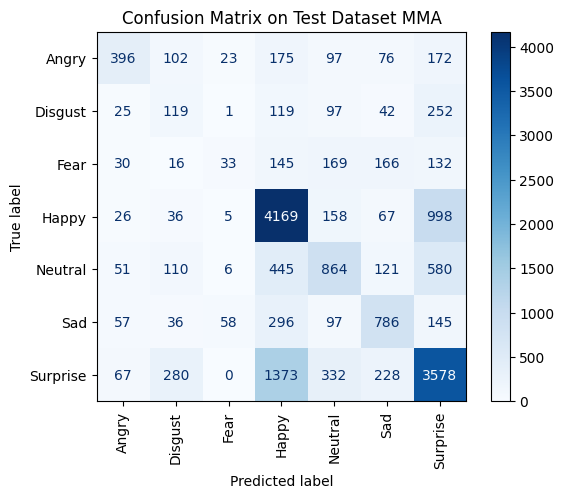

In [58]:
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pylab as plt

print(classification_report(all_labels, all_preds, target_names=class_names))
matrix = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(all_labels, all_preds), display_labels=class_names)

matrix.plot(cmap = 'Blues', xticks_rotation = 90)
plt.title("Confusion Matrix on Test Dataset MMA")
plt.show()

## 14. Sanity Check (No Data Needed)
Run this cell first to verify model forward pass works correctly.

In [ ]:
print('Running sanity check...')
model.eval()

dummy_imgs   = torch.randn(4, 3, 224, 224).to(device)
dummy_labels = torch.randint(0, 7, (4,)).to(device)

# Test phase
with torch.no_grad():
    out, _ = model(dummy_imgs, clip_model, dummy_labels, phase='test')
print(f'Output shape (test) : {out.shape}  (expected: [4, 7])')

# Train phase
model.train()
out, MC_loss = model(dummy_imgs, clip_model, dummy_labels, phase='train')
l_cls = nn.CrossEntropyLoss()(out, dummy_labels)
total = l_cls + 5 * MC_loss[1] + 1.5 * MC_loss[0]

print(f'Output shape (train): {out.shape}  (expected: [4, 7])')
print(f'l_cls  : {l_cls.item():.4f}')
print(f'l_sep  : {MC_loss[0].item():.4f}')
print(f'l_div  : {MC_loss[1].item():.4f}')
print(f'total  : {total.item():.4f}')
print('\nSanity check passed! ✓')

Running sanity check...
Output shape (test) : torch.Size([4, 7])  (expected: [4, 7])
Output shape (train): torch.Size([4, 7])  (expected: [4, 7])
l_cls  : 1.8941
l_sep  : 2.0366
l_div  : 0.9918
total  : 9.9083

Sanity check passed! ✓
